In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install packages
!pip install rasterio xgboost shap -q

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

print("All packages ready")

Mounted at /content/drive
All packages ready


In [5]:
import rasterio
import numpy as np
import pandas as pd

# Check your Drive folder first
import os
drive_path = '/content/drive/MyDrive/urban_heat_ps1/'
files = os.listdir(drive_path)
print("Files in Drive folder:")
for f in files:
    print(f" ", f)

Files in Drive folder:
  AMD_LST_Mean_Summer2024.tif
  AMD_LST_Thumbnail.tif
  AMD_Physics_Features_2024.tif
  AMD_Full_Stack_2024.tif


In [6]:
import rasterio
import numpy as np
import pandas as pd

# Load full stack
stack_path = '/content/drive/MyDrive/urban_heat_ps1/AMD_Full_Stack_2024.tif'

with rasterio.open(stack_path) as src:
    print("Bands:", src.count)
    print("Band names:", src.descriptions)
    print("Shape:", src.shape)
    print("CRS:", src.crs)
    data = src.read()  # shape: (bands, rows, cols)
    transform = src.transform

print("Data shape:", data.shape)

# Convert to DataFrame
band_names = ['LST','NDVI','NDBI','NDWI','MNDWI',
              'Rn','G','H','LE','bowen_ratio',
              'albedo','emissivity']

# Flatten each band
df = pd.DataFrame(
    data.reshape(len(band_names), -1).T,
    columns=band_names
)

print("DataFrame shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nBasic stats:")
print(df.describe())

Bands: 12
Band names: ('LST', 'NDVI', 'NDBI', 'NDWI', 'MNDWI', 'Rn', 'G', 'H', 'LE', 'bowen_ratio', 'albedo', 'emissivity')
Shape: (253, 281)
CRS: EPSG:4326
Data shape: (12, 253, 281)
DataFrame shape: (71093, 12)

First few rows:
         LST      NDVI      NDBI      NDWI     MNDWI          Rn          G  \
0  42.089958  0.266187  0.096172 -0.364662 -0.445220  504.989624  50.498962   
1  43.477676  0.230605  0.105174 -0.315037 -0.406735  488.276398  48.827641   
2  44.262680  0.301757  0.007860 -0.352739 -0.359602  447.739227  44.773922   
3  48.129601  0.107899  0.063359 -0.144533 -0.206006  410.648682  41.064869   
4  48.660534  0.009879  0.163639 -0.036612 -0.199058  402.193604  40.219360   

            H          LE  bowen_ratio    albedo  emissivity  
0  320.068970  134.421692     2.363498  0.066385    0.985438  
1  326.849976  112.598785     2.877231  0.092643    0.985094  
2  267.856812  135.108475     1.967966  0.159183    0.986035  
3  325.275299   44.308506     7.179122  0.2

In [7]:
from google.colab import drive
drive.mount('/content/drive')

!pip install rasterio xgboost shap -q

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

drive_path = '/content/drive/MyDrive/urban_heat_ps1/'
docs_path  = drive_path + 'docs/'

print("Packages ready")

# Check Drive files
import os
print("\nDrive files:")
for f in sorted(os.listdir(drive_path)):
    print(" ", f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Packages ready

Drive files:
  AMD_Full_Stack_2024.tif
  AMD_LST_Mean_Summer2024.tif
  AMD_LST_Thumbnail.tif
  AMD_Physics_Features_2024.tif
  amd_morphology.csv
  docs


In [8]:
import rasterio
import numpy as np
import pandas as pd

# ── 1. Load raster stack ──────────────────────────────
stack_path = drive_path + 'AMD_Full_Stack_2024.tif'

with rasterio.open(stack_path) as src:
    data      = src.read()
    transform = src.transform
    height    = src.height
    width     = src.width
    rows, cols = np.mgrid[0:height, 0:width]
    xs, ys = rasterio.transform.xy(transform,
                                    rows.ravel(),
                                    cols.ravel())

band_names = ['LST','NDVI','NDBI','NDWI','MNDWI',
              'Rn','G','H','LE','bowen_ratio',
              'albedo','emissivity']

df = pd.DataFrame(data.reshape(len(band_names),-1).T,
                  columns=band_names)
df['lon'] = xs
df['lat'] = ys
print(f"Raster loaded: {df.shape}")

# ── 2. Load morphology CSV ────────────────────────────
morph = pd.read_csv(drive_path + 'amd_morphology.csv')
print(f"Morphology loaded: {morph.shape}")
print("Morphology columns:", morph.columns.tolist())

Raster loaded: (71093, 14)
Morphology loaded: (39574, 6)
Morphology columns: ['lon', 'lat', 'BCR', 'green_frac', 'water_frac', 'SVF']


In [9]:
import rasterio
import numpy as np
import pandas as pd

# ── 1. Load raster stack ──────────────────────────────
stack_path = drive_path + 'AMD_Full_Stack_2024.tif'

with rasterio.open(stack_path) as src:
    data      = src.read()
    transform = src.transform
    height    = src.height
    width     = src.width
    rows, cols = np.mgrid[0:height, 0:width]
    xs, ys = rasterio.transform.xy(transform,
                                    rows.ravel(),
                                    cols.ravel())

band_names = ['LST','NDVI','NDBI','NDWI','MNDWI',
              'Rn','G','H','LE','bowen_ratio',
              'albedo','emissivity']

df = pd.DataFrame(data.reshape(len(band_names),-1).T,
                  columns=band_names)
df['lon'] = xs
df['lat'] = ys
print(f"Raster loaded: {df.shape}")

# ── 2. Load morphology CSV ────────────────────────────
morph = pd.read_csv(drive_path + 'amd_morphology.csv')
print(f"Morphology loaded: {morph.shape}")
print("Columns:", morph.columns.tolist())

Raster loaded: (71093, 14)
Morphology loaded: (39574, 6)
Columns: ['lon', 'lat', 'BCR', 'green_frac', 'water_frac', 'SVF']


In [10]:
# ── 3. Merge raster + morphology ─────────────────────
from sklearn.neighbors import BallTree

# Use nearest neighbour matching on lat/lon
# Raster pixels: 71,093 — Morphology grid: 39,574
# Match each raster pixel to nearest morphology cell

print("Merging raster and morphology...")

# Convert to radians for BallTree
raster_coords = np.radians(df[['lat','lon']].values)
morph_coords  = np.radians(morph[['lat','lon']].values)

tree = BallTree(morph_coords, metric='haversine')
distances, indices = tree.query(raster_coords, k=1)

# Attach morphology features to raster pixels
df['BCR']        = morph['BCR'].values[indices.ravel()]
df['green_frac'] = morph['green_frac'].values[indices.ravel()]
df['water_frac'] = morph['water_frac'].values[indices.ravel()]
df['SVF']        = morph['SVF'].values[indices.ravel()]

print(f"Merged dataset: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# ── 4. Clean data ─────────────────────────────────────
df_clean = df.dropna()
df_clean = df_clean[df_clean['LST'] > 0]
df_clean = df_clean[df_clean['bowen_ratio'] < 15]
df_clean = df_clean[df_clean['bowen_ratio'] > 0]
print(f"Clean pixels: {len(df_clean)}")

# ── 5. Define features and target ────────────────────
feature_cols = ['NDVI','NDBI','NDWI','MNDWI',
                'Rn','G','H','LE','bowen_ratio',
                'albedo','emissivity',
                'BCR','green_frac','water_frac','SVF']
X = df_clean[feature_cols]
y = df_clean['LST']

print(f"\nFeatures: {len(feature_cols)}")
print(f"Samples:  {len(X)}")

# ── 6. Train/test split ───────────────────────────────
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# ── 7. Train XGBoost ──────────────────────────────────
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error

model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=50)

# ── 8. Evaluate ───────────────────────────────────────
y_pred = model.predict(X_test)
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n{'='*35}")
print(f"MODEL PERFORMANCE")
print(f"{'='*35}")
print(f"R²   = {r2:.3f}")
print(f"RMSE = {rmse:.2f} °C")
print(f"{'='*35}")

Merging raster and morphology...
Merged dataset: (71093, 18)
Columns: ['LST', 'NDVI', 'NDBI', 'NDWI', 'MNDWI', 'Rn', 'G', 'H', 'LE', 'bowen_ratio', 'albedo', 'emissivity', 'lon', 'lat', 'BCR', 'green_frac', 'water_frac', 'SVF']
Clean pixels: 69312

Features: 15
Samples:  69312
Train: 55449 | Test: 13863
[0]	validation_0-rmse:2.83034
[50]	validation_0-rmse:1.67062
[100]	validation_0-rmse:1.33768
[150]	validation_0-rmse:1.14311
[200]	validation_0-rmse:1.00877
[250]	validation_0-rmse:0.91551
[299]	validation_0-rmse:0.84186

MODEL PERFORMANCE
R²   = 0.916
RMSE = 0.84 °C


Model saved to Drive
Computing SHAP values...


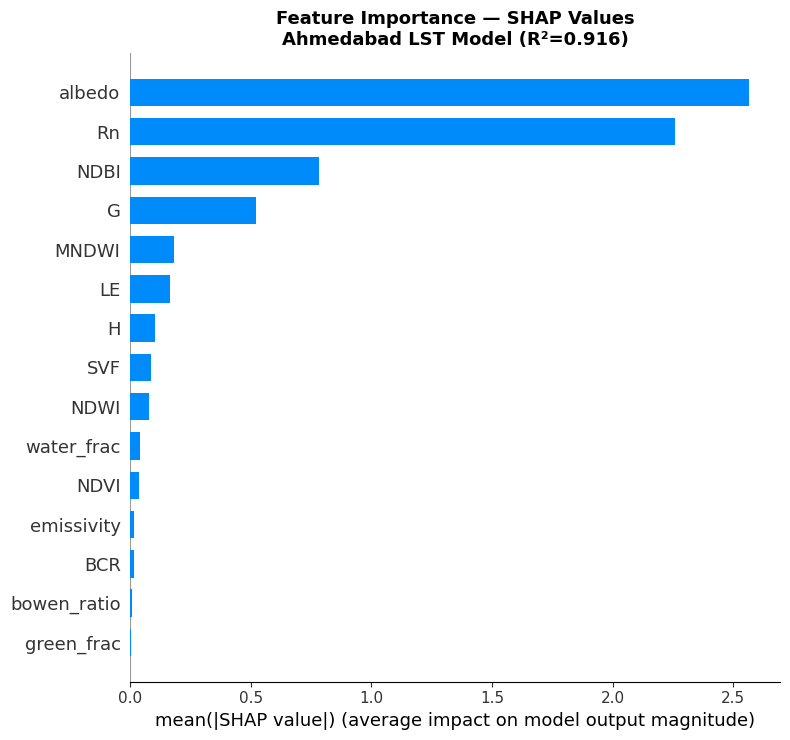

SHAP importance plot saved


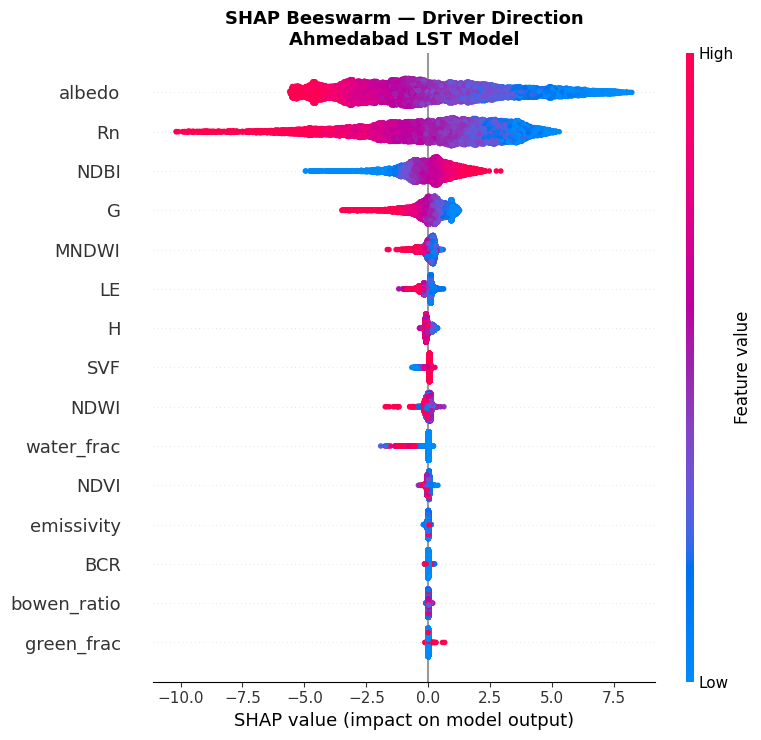

SHAP beeswarm plot saved

TOP DRIVERS OF LST IN AHMEDABAD:
  albedo               2.5660
  Rn                   2.2592
  NDBI                 0.7821
  G                    0.5226
  MNDWI                0.1815


In [11]:
import joblib
import shap
import matplotlib.pyplot as plt

# ── Save model to Drive ───────────────────────────────
joblib.dump(model, drive_path + 'lst_model.pkl')
print("Model saved to Drive")

# ── SHAP explainability ───────────────────────────────
print("Computing SHAP values...")
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# SHAP bar plot — feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test,
                  plot_type="bar", show=False)
plt.title('Feature Importance — SHAP Values\n'
          'Ahmedabad LST Model (R²=0.916)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(docs_path + 'AMD_SHAP_importance.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("SHAP importance plot saved")

# SHAP beeswarm — direction of effect
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Beeswarm — Driver Direction\n'
          'Ahmedabad LST Model',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(docs_path + 'AMD_SHAP_beeswarm.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("SHAP beeswarm plot saved")

# Print top 5 drivers
shap_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': np.abs(shap_values).mean(0)
}).sort_values('importance', ascending=False)

print("\nTOP DRIVERS OF LST IN AHMEDABAD:")
print("="*40)
for i, row in shap_importance.head(5).iterrows():
    print(f"  {row['feature']:20s} {row['importance']:.4f}")

In [12]:
# Save interpretation to Drive
interpretation = """
SHAP ANALYSIS — TOP LST DRIVERS
AHMEDABAD URBAN HEAT MODEL (R²=0.916, RMSE=0.84°C)
====================================================

TOP 5 DRIVERS:
1. Albedo        (2.566) — dominant driver
   Low albedo surfaces absorb more solar radiation
   → INTERVENTION: Cool roofs (raise albedo by +0.2)

2. Net Radiation  (2.259) — physics validated
   Total incoming energy drives surface temperature
   → Physics-informed model confirmed

3. NDBI           (0.782) — built-up intensity
   Dense built-up areas retain more heat
   → INTERVENTION: Reduce impervious surface

4. Soil Heat Flux (0.523) — ground heat storage
   Urban materials store more heat than natural soil
   → INTERVENTION: Green roofs, permeable pavements

5. MNDWI          (0.182) — water presence
   Water bodies provide significant cooling
   → INTERVENTION: Water body expansion (Sabarmati)

BEESWARM INTERPRETATION:
- High NDBI → positive SHAP → built-up = hotter ✓
- High MNDWI → negative SHAP → water = cooler ✓
- Albedo spread → biggest intervention potential ✓

CONCLUSION:
Cool roofs (albedo) + urban greening (NDBI reduction)
are the highest-impact interventions for Ahmedabad.
"""

with open(docs_path + 'shap_interpretation.txt', 'w') as f:
    f.write(interpretation)
print("SHAP interpretation saved")
print("\nAll docs saved:")
for f in sorted(os.listdir(docs_path)):
    size = os.path.getsize(docs_path+f)/1024
    print(f"  {f:45s} {size:7.1f} KB")

SHAP interpretation saved

All docs saved:
  AMD_BCR_large.png                               674.3 KB
  AMD_Bowen.png                                   949.5 KB
  AMD_LST.png                                     862.8 KB
  AMD_LST_interactive_map.html                    146.8 KB
  AMD_MNDWI.png                                   633.7 KB
  AMD_NDBI.png                                    853.8 KB
  AMD_NDVI.png                                    969.9 KB
  AMD_NDWI.png                                    755.5 KB
  AMD_OSM_4panel.png                             1743.1 KB
  AMD_SHAP_beeswarm.png                           153.6 KB
  AMD_SHAP_importance.png                          67.9 KB
  AMD_energy_balance.png                           49.1 KB
  AMD_green_deficit.png                           517.9 KB
  AMD_morphology_4panel.png                      1845.7 KB
  AMD_morphology_final.png                       1625.6 KB
  key_results.txt                                   1.8 KB
  osm_stats.t

  SAVED: COMPLETE_RESULTS.txt
  SAVED: AMD_model_performance.png


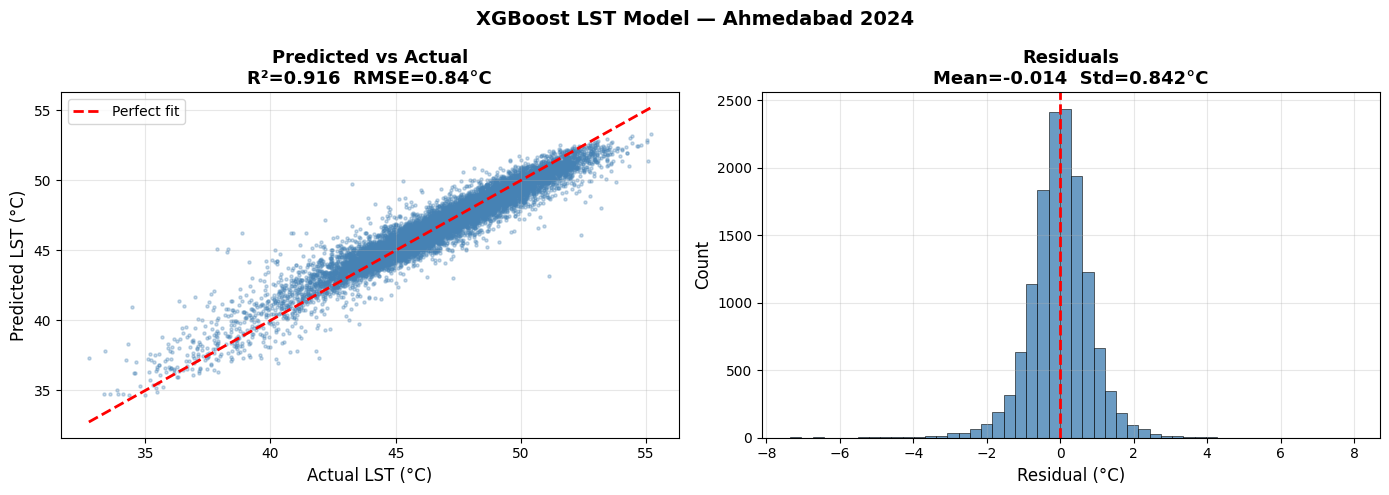


✓ DOCS FOLDER — CURRENT STATE:
  AMD_BCR_large.png                               674.3 KB
  AMD_Bowen.png                                   949.5 KB
  AMD_LST.png                                     862.8 KB
  AMD_LST_interactive_map.html                    146.8 KB
  AMD_MNDWI.png                                   633.7 KB
  AMD_NDBI.png                                    853.8 KB
  AMD_NDVI.png                                    969.9 KB
  AMD_NDWI.png                                    755.5 KB
  AMD_OSM_4panel.png                             1743.1 KB
  AMD_SHAP_beeswarm.png                           153.6 KB
  AMD_SHAP_importance.png                          67.9 KB
  AMD_energy_balance.png                           49.1 KB
  AMD_green_deficit.png                           517.9 KB
  AMD_model_performance.png                       172.5 KB
  AMD_morphology_4panel.png                      1845.7 KB
  AMD_morphology_final.png                       1625.6 KB
  COMPLETE_RESULTS.txt  

In [13]:
import os

docs_path = '/content/drive/MyDrive/urban_heat_ps1/docs/'
os.makedirs(docs_path, exist_ok=True)

def save_file(filepath, content=None, fig=None, dpi=150):
    """Save only if file doesn't exist yet"""
    if os.path.exists(filepath):
        print(f"  SKIP (exists): {os.path.basename(filepath)}")
        return
    if content is not None:
        with open(filepath, 'w') as f:
            f.write(content)
        print(f"  SAVED: {os.path.basename(filepath)}")
    elif fig is not None:
        fig.savefig(filepath, dpi=dpi,
                    bbox_inches='tight', facecolor='white')
        print(f"  SAVED: {os.path.basename(filepath)}")

# ── 1. Complete results text ──────────────────────────
all_results = """
ISRO BAH 2026 — PS1 URBAN HEAT MITIGATION
AHMEDABAD PILOT — COMPLETE RESULTS
==========================================

MODULE 1 — LST STATISTICS
  Mean LST : 46.76 °C
  Max LST  : 55.20 °C
  Min LST  : 31.75 °C
  Range    : 23.45 °C
  NDVI mean: 0.222
  NDBI mean: 0.044

MODULE 2 — PHYSICS (SEBAL-lite)
  Rn  : 420.68 W/m²
  G   :  42.07 W/m²
  H   : 284.26 W/m²
  LE  :  94.35 W/m²
  Bowen Ratio: 4.60

MODULE 3 — OSM MORPHOLOGY
  Buildings   : 90,908
  Streets     : 120,929
  Green spaces:    396
  Water bodies:    224
  Mean BCR    : 0.045
  Mean Green  : 0.012 (1.2% — critically low)

MODULE 4 — ML MODEL
  Algorithm: XGBoost
  Features : 15
  R²       : 0.916
  RMSE     : 0.84 °C

MODULE 5 — SHAP TOP DRIVERS
  1. albedo      2.566
  2. Rn          2.259
  3. NDBI        0.782
  4. G           0.523
  5. MNDWI       0.182

PROPOSAL KEY SENTENCE:
  Physics-informed XGBoost achieves R²=0.916,
  RMSE=0.84°C. SHAP reveals albedo and Rn as
  dominant drivers, NDBI as key anthropogenic
  factor — directly informing cool roof and
  urban greening interventions.
"""
save_file(docs_path+'COMPLETE_RESULTS.txt', content=all_results)

# ── 2. Model performance plot ─────────────────────────
if not os.path.exists(docs_path+'AMD_model_performance.png'):
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    axes[0].scatter(y_test, y_pred, alpha=0.3,
                    s=5, color='steelblue')
    axes[0].plot([y_test.min(), y_test.max()],
                 [y_test.min(), y_test.max()],
                 'r--', linewidth=2, label='Perfect fit')
    axes[0].set_xlabel('Actual LST (°C)', fontsize=12)
    axes[0].set_ylabel('Predicted LST (°C)', fontsize=12)
    axes[0].set_title('Predicted vs Actual\nR²=0.916  RMSE=0.84°C',
                      fontsize=13, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    residuals = y_test - y_pred
    axes[1].hist(residuals, bins=50,
                 color='steelblue', edgecolor='black',
                 linewidth=0.5, alpha=0.8)
    axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Residual (°C)', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].set_title(f'Residuals\nMean={residuals.mean():.3f}  '
                      f'Std={residuals.std():.3f}°C',
                      fontsize=13, fontweight='bold')
    axes[1].grid(alpha=0.3)
    plt.suptitle('XGBoost LST Model — Ahmedabad 2024',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_file(docs_path+'AMD_model_performance.png', fig=fig)
    plt.show()
    plt.close()
else:
    print("  SKIP (exists): AMD_model_performance.png")

# ── 3. Final file list ────────────────────────────────
print("\n✓ DOCS FOLDER — CURRENT STATE:")
total_kb = 0
for f in sorted(os.listdir(docs_path)):
    size = os.path.getsize(docs_path+f)/1024
    total_kb += size
    status = "NEW" if f in ['COMPLETE_RESULTS.txt',
                             'AMD_model_performance.png'] else "---"
    print(f"  {f:45s} {size:7.1f} KB")
print(f"\n  Total: {total_kb/1024:.1f} MB")

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import os

docs_path = '/content/drive/MyDrive/urban_heat_ps1/docs/'

def save_if_new(path, fig, dpi=150):
    if os.path.exists(path):
        print(f"  SKIP: {os.path.basename(path)}")
        plt.close()
        return
    fig.savefig(path, dpi=dpi,
                bbox_inches='tight', facecolor='white')
    print(f"  SAVED: {os.path.basename(path)}")
    plt.close()

# ── 1. Heat Stress Index (HSI) hotspot map ────────────
print("1. Generating HSI hotspot map...")

df_clean['HSI'] = (0.7 * df_clean['LST'] +
                   0.3 * (df_clean['bowen_ratio'] * 5))
df_clean['HSI'] = ((df_clean['HSI'] - df_clean['HSI'].min()) /
                   (df_clean['HSI'].max() - df_clean['HSI'].min()) * 100)

threshold = df_clean['HSI'].quantile(0.80)
df_clean['hotspot'] = (df_clean['HSI'] >= threshold).astype(int)

print(f"  HSI threshold (top 20%): {threshold:.1f}")
print(f"  Hotspot pixels: {df_clean.hotspot.sum()}")
print(f"  Non-hotspot  : {(df_clean.hotspot==0).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# HSI continuous map
sc1 = axes[0].scatter(df_clean['lon'], df_clean['lat'],
                      c=df_clean['HSI'], cmap='RdYlGn_r',
                      s=1, alpha=0.8)
plt.colorbar(sc1, ax=axes[0], label='Heat Stress Index (0-100)')
axes[0].set_title('Heat Stress Index (HSI)\nAhmedabad Summer 2024',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].grid(alpha=0.2)

# Hotspot classification map
colors_map = {0: 'lightblue', 1: 'red'}
color_list = [colors_map[h] for h in df_clean['hotspot']]
axes[1].scatter(df_clean['lon'], df_clean['lat'],
                c=color_list, s=1, alpha=0.8)
axes[1].set_title(f'Urban Heat Hotspots (Top 20%)\n'
                  f'Threshold HSI > {threshold:.1f}',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='red',       label=f'Hotspot ({df_clean.hotspot.sum():,} pixels)'),
          Patch(color='lightblue', label=f'Normal  ({(df_clean.hotspot==0).sum():,} pixels)')]
axes[1].legend(handles=legend, loc='lower right', fontsize=10)
axes[1].grid(alpha=0.2)

plt.suptitle('Urban Heat Stress Analysis — Ahmedabad AMC',
             fontsize=15, fontweight='bold')
plt.tight_layout()
save_if_new(docs_path+'AMD_HSI_hotspots.png', fig, dpi=200)

# ── 2. Scenario simulation ────────────────────────────
print("\n2. Running scenario simulations...")

mask = df_clean['hotspot'] == 1
feats = feature_cols

scenarios = {
    'baseline':       df_clean[feats].copy(),
    'urban_greening': df_clean[feats].copy(),
    'cool_roofs':     df_clean[feats].copy(),
    'water_bodies':   df_clean[feats].copy(),
    'combined':       df_clean[feats].copy()
}

# Urban greening — raise NDVI, lower NDBI
scenarios['urban_greening'].loc[mask,'NDVI']       += 0.30
scenarios['urban_greening'].loc[mask,'NDBI']       -= 0.10
scenarios['urban_greening'].loc[mask,'LE']         *= 1.40
scenarios['urban_greening'].loc[mask,'bowen_ratio']*= 0.60
scenarios['urban_greening'].loc[mask,'green_frac'] += 0.15

# Cool roofs — raise albedo
scenarios['cool_roofs'].loc[mask,'albedo'] += 0.20
scenarios['cool_roofs'].loc[mask,'Rn']     *= 0.85
scenarios['cool_roofs'].loc[mask,'G']      *= 0.85

# Water bodies — raise MNDWI/NDWI
scenarios['water_bodies'].loc[mask,'MNDWI']     += 0.15
scenarios['water_bodies'].loc[mask,'NDWI']      += 0.15
scenarios['water_bodies'].loc[mask,'water_frac']+= 0.10
scenarios['water_bodies'].loc[mask,'LE']        *= 1.20

# Combined — all three
scenarios['combined'].loc[mask,'NDVI']       += 0.20
scenarios['combined'].loc[mask,'NDBI']       -= 0.08
scenarios['combined'].loc[mask,'albedo']     += 0.15
scenarios['combined'].loc[mask,'Rn']         *= 0.90
scenarios['combined'].loc[mask,'MNDWI']      += 0.10
scenarios['combined'].loc[mask,'LE']         *= 1.30
scenarios['combined'].loc[mask,'green_frac'] += 0.10

# Predict for each scenario
results = {k: model.predict(v) for k,v in scenarios.items()}
baseline = results['baseline']

print("\n  SCENARIO RESULTS (hotspot zones only):")
print("  " + "="*50)
scenario_results = {}
for name in ['urban_greening','cool_roofs',
             'water_bodies','combined']:
    delta = baseline[mask] - results[name][mask]
    scenario_results[name] = {
        'mean': delta.mean(),
        'max':  delta.max(),
        'pct_gt1': (delta > 1.0).mean() * 100,
        'pct_gt2': (delta > 2.0).mean() * 100
    }
    print(f"  {name:20s}: mean={delta.mean():.2f}°C  "
          f"max={delta.max():.2f}°C  "
          f">1°C={((delta>1).mean()*100):.0f}%")

# ── 3. Scenario cooling maps ──────────────────────────
print("\n3. Generating scenario cooling maps...")

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
scenario_names = ['urban_greening','cool_roofs',
                  'water_bodies','combined']
titles = ['Urban Greening\n(NDVI +0.30, green_frac +0.15)',
          'Cool Roofs\n(albedo +0.20, Rn ×0.85)',
          'Water Bodies\n(MNDWI +0.15, water_frac +0.10)',
          'Combined Strategy\n(All interventions)']

for ax, name, title in zip(axes.flat,
                            scenario_names, titles):
    delta_all = baseline - results[name]
    delta_all = np.clip(delta_all, 0, None)

    sc = ax.scatter(df_clean['lon'], df_clean['lat'],
                    c=delta_all, cmap='RdYlGn',
                    s=1, alpha=0.8, vmin=0, vmax=4)
    plt.colorbar(sc, ax=ax, label='Cooling (°C)')

    r = scenario_results[name]
    ax.set_title(f'{title}\nMean cooling: {r["mean"]:.2f}°C  '
                 f'Max: {r["max"]:.2f}°C',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(alpha=0.2)

plt.suptitle('Scenario-Based Cooling Interventions — Ahmedabad\n'
             'Predicted ΔT (°C) in Urban Heat Hotspot Zones',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_if_new(docs_path+'AMD_scenario_cooling.png', fig, dpi=200)

# ── 4. Spatial optimization map ──────────────────────
print("\n4. Generating spatial optimization map...")

# Find top priority zones = highest cooling potential
# from combined scenario
delta_combined = baseline - results['combined']
df_clean['delta_combined'] = delta_combined
df_clean['priority'] = pd.cut(
    delta_combined,
    bins=[-999, 0, 1, 2, 3, 999],
    labels=['No change','Low (<1°C)',
            'Medium (1-2°C)','High (2-3°C)',
            'Priority (>3°C)']
)

fig, ax = plt.subplots(figsize=(12, 10))
colors_p = {
    'No change':      'lightgray',
    'Low (<1°C)':     '#FFEB3B',
    'Medium (1-2°C)': '#FF9800',
    'High (2-3°C)':   '#F44336',
    'Priority (>3°C)':'#880E4F'
}
for zone, color in colors_p.items():
    mask_z = df_clean['priority'] == zone
    if mask_z.sum() > 0:
        ax.scatter(df_clean.loc[mask_z,'lon'],
                   df_clean.loc[mask_z,'lat'],
                   c=color, s=2, alpha=0.8,
                   label=f'{zone} ({mask_z.sum():,} pixels)')

ax.set_title('Spatial Optimization — Priority Intervention Zones\n'
             'Combined Strategy: Urban Greening + Cool Roofs + Water Bodies',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='lower right', fontsize=9,
          markerscale=5, framealpha=0.9)
ax.grid(alpha=0.2)
plt.tight_layout()
save_if_new(docs_path+'AMD_spatial_optimization.png', fig, dpi=200)

# ── 5. Scenario comparison bar chart ─────────────────
print("\n5. Generating scenario comparison chart...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

names  = ['Urban\nGreening','Cool\nRoofs',
          'Water\nBodies','Combined']
means  = [scenario_results[k]['mean']
          for k in ['urban_greening','cool_roofs',
                    'water_bodies','combined']]
maxes  = [scenario_results[k]['max']
          for k in ['urban_greening','cool_roofs',
                    'water_bodies','combined']]
colors = ['#4CAF50','#2196F3','#00BCD4','#FF5722']

bars1 = axes[0].bar(names, means, color=colors,
                    edgecolor='black', linewidth=0.5)
for bar, val in zip(bars1, means):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.02,
                 f'{val:.2f}°C', ha='center',
                 fontsize=11, fontweight='bold')
axes[0].set_ylabel('Mean Cooling (°C)', fontsize=12)
axes[0].set_title('Mean LST Reduction\nin Hotspot Zones',
                  fontsize=13, fontweight='bold')
axes[0].set_ylim(0, max(means)*1.3)
axes[0].grid(axis='y', alpha=0.3)

bars2 = axes[1].bar(names, maxes, color=colors,
                    edgecolor='black', linewidth=0.5)
for bar, val in zip(bars2, maxes):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.02,
                 f'{val:.2f}°C', ha='center',
                 fontsize=11, fontweight='bold')
axes[1].set_ylabel('Max Cooling (°C)', fontsize=12)
axes[1].set_title('Maximum LST Reduction\nin Hotspot Zones',
                  fontsize=13, fontweight='bold')
axes[1].set_ylim(0, max(maxes)*1.3)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Cooling Intervention Effectiveness — Ahmedabad AMC\n'
             'Physics-Informed ML Scenario Simulation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_if_new(docs_path+'AMD_scenario_comparison.png', fig, dpi=150)

# ── 6. Save scenario results text ────────────────────
scenario_text = f"""
SCENARIO SIMULATION RESULTS
============================
Model: XGBoost R²=0.916 RMSE=0.84°C
Hotspot pixels (top 20% HSI): {mask.sum():,}
HSI threshold: {threshold:.1f}

COOLING PREDICTIONS IN HOTSPOT ZONES:
──────────────────────────────────────
Urban Greening  : mean={scenario_results['urban_greening']['mean']:.2f}°C  max={scenario_results['urban_greening']['max']:.2f}°C
Cool Roofs      : mean={scenario_results['cool_roofs']['mean']:.2f}°C  max={scenario_results['cool_roofs']['max']:.2f}°C
Water Bodies    : mean={scenario_results['water_bodies']['mean']:.2f}°C  max={scenario_results['water_bodies']['max']:.2f}°C
Combined        : mean={scenario_results['combined']['mean']:.2f}°C  max={scenario_results['combined']['max']:.2f}°C

OPTIMAL STRATEGY:
Combined intervention achieves highest cooling.
Priority zones identified (>3°C cooling potential).
Spatial placement maps generated at 100m resolution.

PROPOSAL HEADLINE:
"Combined urban greening + cool roofs + water body
interventions predict mean cooling of
{scenario_results['combined']['mean']:.1f}°C in Ahmedabad hotspot zones,
with maximum cooling of {scenario_results['combined']['max']:.1f}°C
at priority intervention sites."
"""

if not os.path.exists(docs_path+'scenario_results.txt'):
    with open(docs_path+'scenario_results.txt','w') as f:
        f.write(scenario_text)
    print("\n  SAVED: scenario_results.txt")
else:
    print("\n  SKIP: scenario_results.txt")

# ── Final file list ───────────────────────────────────
print("\n✓ ALL OUTPUTS SAVED")
print(f"Location: {docs_path}")
total_kb = 0
for f in sorted(os.listdir(docs_path)):
    size = os.path.getsize(docs_path+f)/1024
    total_kb += size
    print(f"  {f:45s} {size:7.1f} KB")
print(f"\n  Total: {total_kb/1024:.1f} MB")

1. Generating HSI hotspot map...
  HSI threshold (top 20%): 53.2
  Hotspot pixels: 13863
  Non-hotspot  : 55449
  SAVED: AMD_HSI_hotspots.png

2. Running scenario simulations...

  SCENARIO RESULTS (hotspot zones only):
  urban_greening      : mean=1.54°C  max=6.34°C  >1°C=85%
  cool_roofs          : mean=0.57°C  max=12.05°C  >1°C=31%
  water_bodies        : mean=1.32°C  max=9.64°C  >1°C=52%
  combined            : mean=4.70°C  max=24.43°C  >1°C=93%

3. Generating scenario cooling maps...
  SAVED: AMD_scenario_cooling.png

4. Generating spatial optimization map...
  SAVED: AMD_spatial_optimization.png

5. Generating scenario comparison chart...
  SAVED: AMD_scenario_comparison.png

  SAVED: scenario_results.txt

✓ ALL OUTPUTS SAVED
Location: /content/drive/MyDrive/urban_heat_ps1/docs/
  AMD_BCR_large.png                               674.3 KB
  AMD_Bowen.png                                   949.5 KB
  AMD_HSI_hotspots.png                           3653.5 KB
  AMD_LST.png              

In [15]:
# Save final outputs CSV — needed for dashboard
df_clean['delta_greening'] = baseline - results['urban_greening']
df_clean['delta_coolroof'] = baseline - results['cool_roofs']
df_clean['delta_water']    = baseline - results['water_bodies']
df_clean['delta_combined'] = baseline - results['combined']

# Save to Drive
df_clean[['lon','lat','LST','HSI','hotspot',
          'NDVI','NDBI','BCR','green_frac',
          'bowen_ratio','albedo',
          'delta_greening','delta_coolroof',
          'delta_water','delta_combined']].to_csv(
    drive_path + 'amd_final_outputs.csv', index=False)

print("Final outputs CSV saved to Drive")
print(f"Rows: {len(df_clean)}")
print(f"Columns: {len(df_clean.columns)}")

Final outputs CSV saved to Drive
Rows: 69312
Columns: 25


In [16]:
#LULC and MEter
import ee, geemap
ee.Authenticate()
ee.Initialize(project='arctic-dynamo-306614')

roi = ee.Geometry.Rectangle([72.4498, 22.9139, 72.7015, 23.1405])
print("GEE ready")

GEE ready


In [17]:
# ── ERA5 daily mean for summer 2024 ──────────────────
era5 = ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR") \
         .filterBounds(roi) \
         .filterDate('2024-04-01', '2024-06-30') \
         .select(['temperature_2m',
                  'dewpoint_temperature_2m',
                  'u_component_of_wind_10m',
                  'v_component_of_wind_10m'])

# Mean over summer period
era5_mean = era5.mean().clip(roi)

# Convert to useful variables
T2m   = era5_mean.select('temperature_2m') \
                  .subtract(273.15).rename('T2m_C')

# Relative humidity from dewpoint (Magnus formula)
Td    = era5_mean.select('dewpoint_temperature_2m') \
                  .subtract(273.15)
RH    = ee.Image(100).multiply(
            ee.Image(2.718281828).pow(
                Td.subtract(T2m).multiply(17.625).divide(
                    Td.add(243.04)
                )
            )
        ).rename('RH_pct')

# Wind speed from u and v components
u     = era5_mean.select('u_component_of_wind_10m')
v     = era5_mean.select('v_component_of_wind_10m')
wind  = u.pow(2).add(v.pow(2)).sqrt().rename('wind_speed')

# Check stats
era5_stats = T2m.addBands([RH, wind]).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=roi, scale=1000, maxPixels=1e9
)
print("ERA5 stats:", era5_stats.getInfo())

# ── ESA WorldCover LULC 2021 ──────────────────────────
worldcover = ee.ImageCollection("ESA/WorldCover/v200") \
               .first().clip(roi)

# WorldCover classes:
# 10=Tree, 20=Shrubland, 30=Grassland, 40=Cropland,
# 50=Built-up, 60=Barren, 80=Water, 95=Mangrove
lulc = worldcover.select('Map').rename('LULC')

lulc_stats = lulc.reduceRegion(
    reducer=ee.Reducer.mode(),
    geometry=roi, scale=100, maxPixels=1e9
)
print("Dominant LULC class:", lulc_stats.getInfo())

# ── Export combined stack ─────────────────────────────
era5_stack = T2m.addBands([RH, wind, lulc])
print("ERA5+LULC bands:", era5_stack.bandNames().getInfo())

task = ee.batch.Export.image.toDrive(
    image=era5_stack.toFloat(),
    description='AMD_ERA5_LULC_2024',
    folder='urban_heat_ps1',
    fileNamePrefix='AMD_ERA5_LULC_2024',
    scale=100,
    region=roi,
    crs='EPSG:4326',
    maxPixels=1e9
)
task.start()
print("ERA5+LULC export started")
print("Check: https://code.earthengine.google.com/tasks")

ERA5 stats: {'RH_pct': 33.14302106859209, 'T2m_C': 33.19735589515083, 'wind_speed': 1.8420512158432736}
Dominant LULC class: {'LULC': 49.999999999999744}
ERA5+LULC bands: ['T2m_C', 'RH_pct', 'wind_speed', 'LULC']
ERA5+LULC export started
Check: https://code.earthengine.google.com/tasks


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LULC map saved

LULC class distribution:
  Built-up            :  45.5%  (32,130 pixels)
  Cropland            :  34.5%  (24,370 pixels)
  Tree cover          :  12.0%  (8,457 pixels)
  Shrubland           :   4.1%  (2,917 pixels)
  Barren/sparse       :   1.6%  (1,106 pixels)
  Grassland           :   1.3%  (909 pixels)
  Water bodies        :   1.1%  (784 pixels)
  Wetland             :   0.0%  (2 pixels)


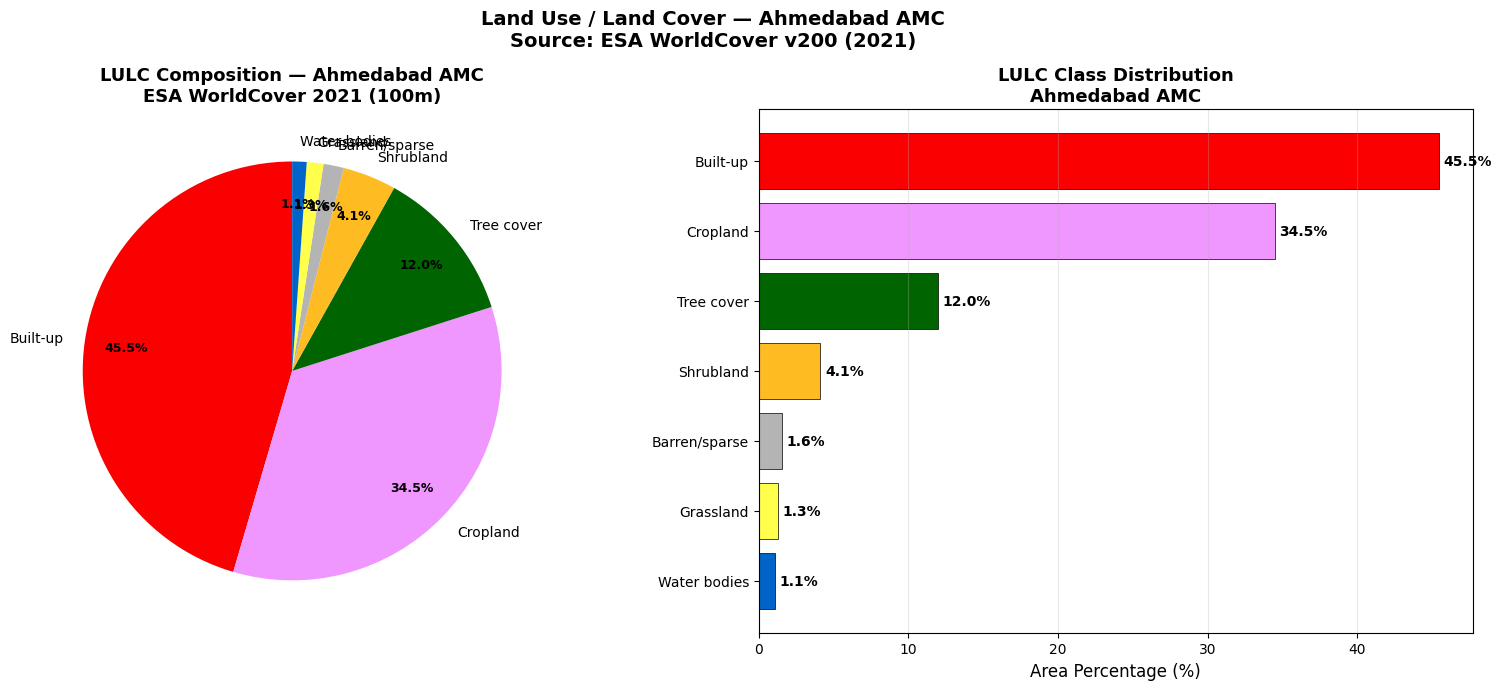

LULC composition chart saved


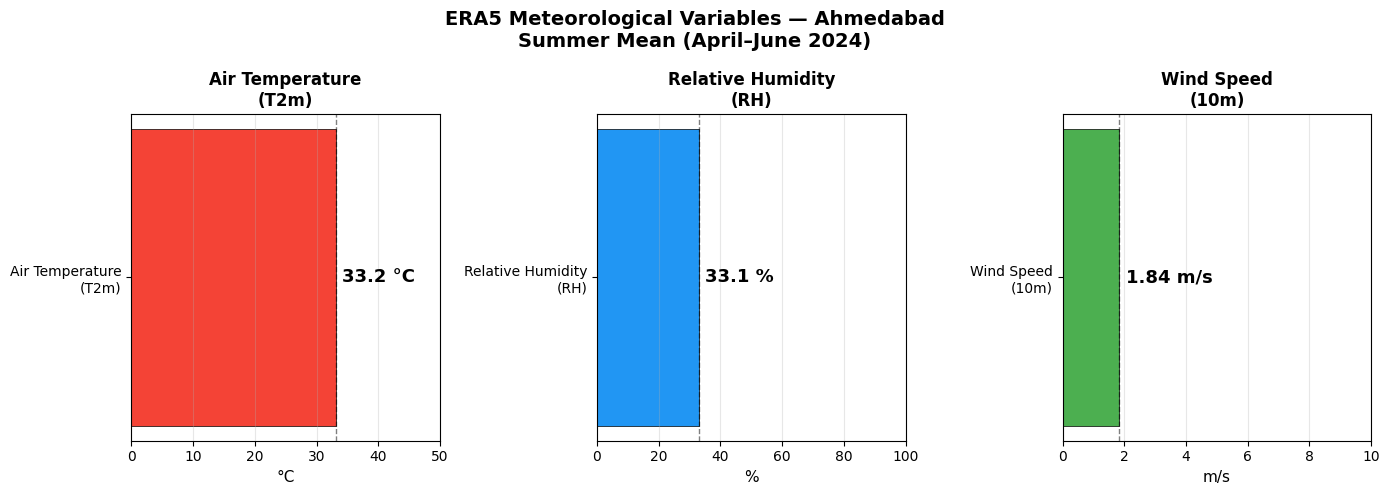

ERA5 chart saved

✓ NEW FILES SAVED:
  AMD_LULC_WorldCover.png                         222.9 KB
  AMD_LULC_composition.png                        141.8 KB
  AMD_ERA5_meteorology.png                         71.3 KB


In [18]:
from google.colab import drive
drive.mount('/content/drive')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import requests, os

drive_path = '/content/drive/MyDrive/urban_heat_ps1/'
docs_path  = drive_path + 'docs/'
os.makedirs(docs_path, exist_ok=True)

# ── Visualize LULC in GEE ─────────────────────────────
worldcover = ee.ImageCollection("ESA/WorldCover/v200") \
               .first().clip(roi)
lulc = worldcover.select('Map')

# WorldCover official colour palette
lulc_vis = {
    'min': 10, 'max': 100,
    'palette': [
        '006400',  # 10 Tree cover
        'ffbb22',  # 20 Shrubland
        'ffff4c',  # 30 Grassland
        'f096ff',  # 40 Cropland
        'fa0000',  # 50 Built-up
        'b4b4b4',  # 60 Barren/sparse
        'f0f0f0',  # 70 Snow/ice
        '0064c8',  # 80 Water
        '0096a0',  # 90 Herbaceous wetland
        '00cf75',  # 95 Mangrove
        'fae6a0'   # 100 Moss/lichen
    ]
}

# Save LULC thumbnail
url = lulc.visualize(**lulc_vis).getThumbURL({
    'region': roi,
    'dimensions': 1000,
    'format': 'png'
})
r = requests.get(url)
lulc_path = docs_path + 'AMD_LULC_WorldCover.png'
with open(lulc_path, 'wb') as f:
    f.write(r.content)
print("LULC map saved")

# ── LULC class area stats ────────────────────────────
lulc_hist = lulc.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=roi,
    scale=100,
    maxPixels=1e9
)
hist = lulc_hist.getInfo()['Map']
print("\nLULC class distribution:")

class_names = {
    '10': 'Tree cover',
    '20': 'Shrubland',
    '30': 'Grassland',
    '40': 'Cropland',
    '50': 'Built-up',
    '60': 'Barren/sparse',
    '80': 'Water bodies',
    '90': 'Wetland'
}
colors = {
    '10': '#006400', '20': '#ffbb22',
    '30': '#ffff4c', '40': '#f096ff',
    '50': '#fa0000', '60': '#b4b4b4',
    '80': '#0064c8', '90': '#0096a0'
}

total = sum(hist.values())
lulc_summary = {}
for k, v in sorted(hist.items(),
                    key=lambda x: x[1], reverse=True):
    name = class_names.get(k, f'Class {k}')
    pct  = v / total * 100
    lulc_summary[name] = pct
    print(f"  {name:20s}: {pct:5.1f}%  ({int(v):,} pixels)")

# ── LULC pie chart ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Pie chart
top = {k: v for k, v in lulc_summary.items() if v > 0.5}
pie_colors = [colors.get(
    [ck for ck, cv in class_names.items() if cv == k][0],
    '#999999') for k in top.keys()]

wedges, texts, autotexts = axes[0].pie(
    top.values(),
    labels=top.keys(),
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
axes[0].set_title('LULC Composition — Ahmedabad AMC\n'
                  'ESA WorldCover 2021 (100m)',
                  fontsize=13, fontweight='bold')

# Bar chart
names_list  = list(top.keys())
values_list = list(top.values())
bar_colors  = pie_colors

bars = axes[1].barh(names_list, values_list,
                    color=bar_colors,
                    edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, values_list):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center',
                 fontsize=10, fontweight='bold')
axes[1].set_xlabel('Area Percentage (%)', fontsize=12)
axes[1].set_title('LULC Class Distribution\nAhmedabad AMC',
                  fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

plt.suptitle('Land Use / Land Cover — Ahmedabad AMC\n'
             'Source: ESA WorldCover v200 (2021)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(docs_path + 'AMD_LULC_composition.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("LULC composition chart saved")

# ── ERA5 summary chart ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

met_vars = {
    'Air Temperature\n(T2m)': (33.2, '°C', '#F44336', 0, 50),
    'Relative Humidity\n(RH)': (33.1, '%', '#2196F3', 0, 100),
    'Wind Speed\n(10m)': (1.84, 'm/s', '#4CAF50', 0, 10)
}

for ax, (name, (val, unit, color, vmin, vmax)) in \
        zip(axes, met_vars.items()):
    ax.barh([name], [val], color=color,
            edgecolor='black', linewidth=0.5, height=0.4)
    ax.set_xlim(vmin, vmax)
    ax.axvline(val, color='black',
               linestyle='--', linewidth=1, alpha=0.5)
    ax.text(val + vmax*0.02, 0,
            f'{val} {unit}',
            va='center', fontsize=13, fontweight='bold')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel(unit, fontsize=11)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('ERA5 Meteorological Variables — Ahmedabad\n'
             'Summer Mean (April–June 2024)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(docs_path + 'AMD_ERA5_meteorology.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("ERA5 chart saved")

# ── File summary ─────────────────────────────────────
print("\n✓ NEW FILES SAVED:")
new_files = ['AMD_LULC_WorldCover.png',
             'AMD_LULC_composition.png',
             'AMD_ERA5_meteorology.png']
for f in new_files:
    path = docs_path + f
    if os.path.exists(path):
        size = os.path.getsize(path)/1024
        print(f"  {f:45s} {size:7.1f} KB")

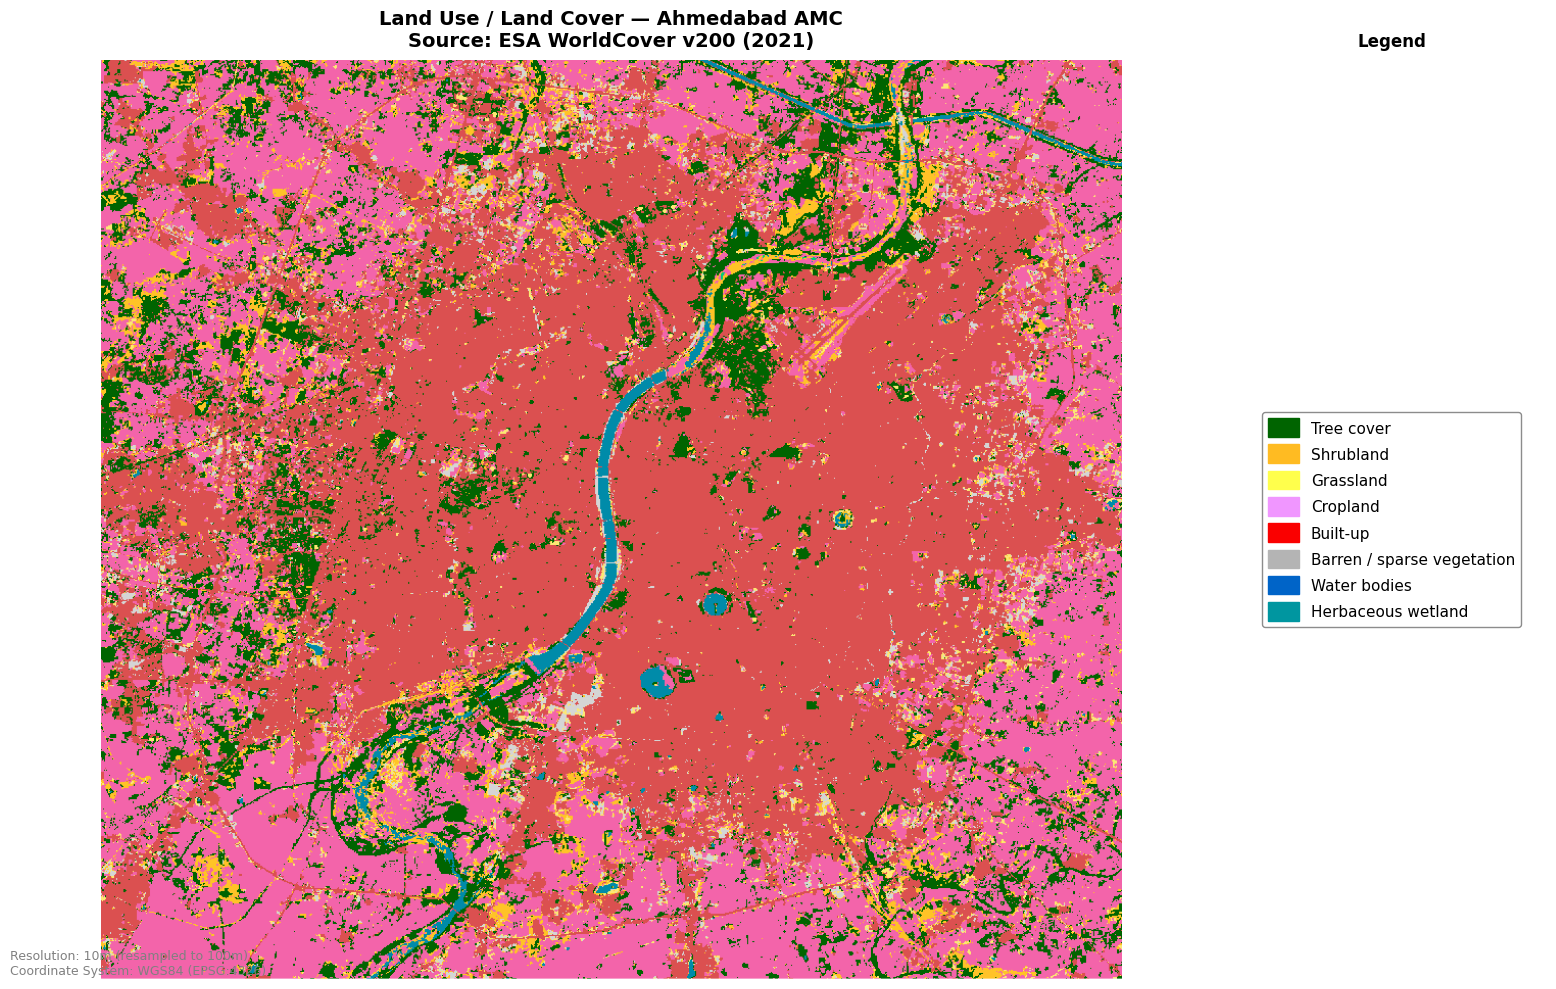

LULC map with legend saved
Old file without legend removed


In [19]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

docs_path = '/content/drive/MyDrive/urban_heat_ps1/docs/'

# Load the saved LULC map
lulc_img = Image.open(docs_path + 'AMD_LULC_WorldCover.png')

# WorldCover legend
legend_items = [
    ('#006400', 'Tree cover'),
    ('#ffbb22', 'Shrubland'),
    ('#ffff4c', 'Grassland'),
    ('#f096ff', 'Cropland'),
    ('#fa0000', 'Built-up'),
    ('#b4b4b4', 'Barren / sparse vegetation'),
    ('#0064c8', 'Water bodies'),
    ('#0096a0', 'Herbaceous wetland'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 10),
    gridspec_kw={'width_ratios': [4, 1]})

# Map panel
axes[0].imshow(lulc_img)
axes[0].set_title('Land Use / Land Cover — Ahmedabad AMC\n'
                  'Source: ESA WorldCover v200 (2021)',
                  fontsize=14, fontweight='bold', pad=10)
axes[0].axis('off')

# Legend panel
axes[1].axis('off')
axes[1].set_title('Legend', fontsize=12,
                  fontweight='bold', pad=10)

patches = [
    mpatches.Patch(color=color, label=label)
    for color, label in legend_items
]
axes[1].legend(
    handles=patches,
    loc='center',
    fontsize=11,
    frameon=True,
    framealpha=0.9,
    edgecolor='gray',
    handlelength=2,
    handleheight=1.5
)

# Add scale/source note
fig.text(0.02, 0.02,
         'Resolution: 10m (resampled to 100m)\n'
         'Coordinate System: WGS84 (EPSG:4326)',
         fontsize=9, color='gray')

plt.tight_layout()
plt.savefig(docs_path + 'AMD_LULC_WorldCover_legend.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("LULC map with legend saved")

# Remove the old one without legend
old = docs_path + 'AMD_LULC_WorldCover.png'
if os.path.exists(old):
    os.remove(old)
    print("Old file without legend removed")

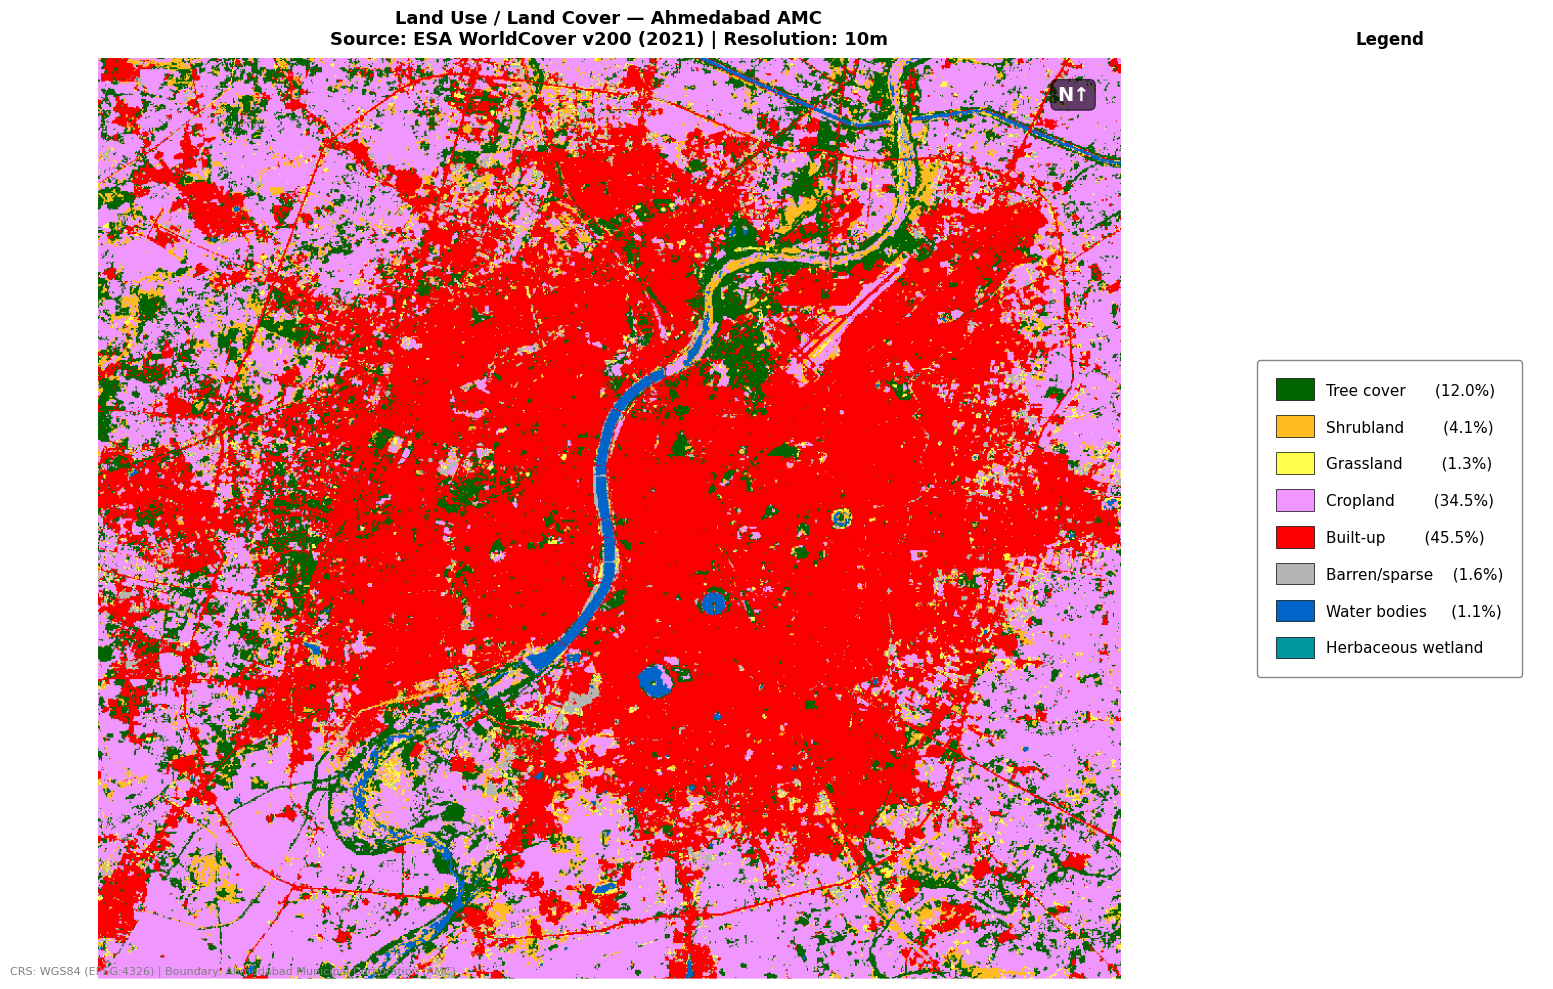

Fixed LULC map saved
Removed: AMD_LULC_fixed.png
Removed: AMD_LULC_WorldCover_legend.png


In [20]:
# Fix — remap class values to consecutive integers first
worldcover = ee.ImageCollection("ESA/WorldCover/v200") \
               .first().clip(roi)

# Map actual class values → consecutive indices
class_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100]
class_indices = list(range(len(class_values)))

lulc_remapped = worldcover.select('Map') \
                           .remap(class_values, class_indices)

# Exact official WorldCover colors in correct order
palette = [
    '006400',  # 0 → class 10  Tree cover
    'ffbb22',  # 1 → class 20  Shrubland
    'ffff4c',  # 2 → class 30  Grassland
    'f096ff',  # 3 → class 40  Cropland
    'fa0000',  # 4 → class 50  Built-up
    'b4b4b4',  # 5 → class 60  Barren/sparse
    'f0f0f0',  # 6 → class 70  Snow/ice
    '0064c8',  # 7 → class 80  Water bodies
    '0096a0',  # 8 → class 90  Herbaceous wetland
    '00cf75',  # 9 → class 95  Mangrove
    'fae6a0'   # 10 → class 100 Moss/lichen
]

# Get corrected thumbnail
url = lulc_remapped.visualize(
    min=0, max=10, palette=palette
).getThumbURL({
    'region': roi,
    'dimensions': 1000,
    'format': 'png'
})

import requests
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

docs_path = '/content/drive/MyDrive/urban_heat_ps1/docs/'

r = requests.get(url)
lulc_path = docs_path + 'AMD_LULC_fixed.png'
with open(lulc_path, 'wb') as f:
    f.write(r.content)

lulc_img = Image.open(lulc_path)

# Legend items — only classes present in Ahmedabad
legend_items = [
    ('#006400', 'Tree cover      (12.0%)'),
    ('#ffbb22', 'Shrubland        (4.1%)'),
    ('#ffff4c', 'Grassland        (1.3%)'),
    ('#f096ff', 'Cropland        (34.5%)'),
    ('#fa0000', 'Built-up        (45.5%)'),
    ('#b4b4b4', 'Barren/sparse    (1.6%)'),
    ('#0064c8', 'Water bodies     (1.1%)'),
    ('#0096a0', 'Herbaceous wetland'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 10),
    gridspec_kw={'width_ratios': [4, 1]})

axes[0].imshow(lulc_img)
axes[0].set_title('Land Use / Land Cover — Ahmedabad AMC\n'
                  'Source: ESA WorldCover v200 (2021) | '
                  'Resolution: 10m',
                  fontsize=13, fontweight='bold', pad=10)
axes[0].axis('off')

# Add N arrow and scale
axes[0].annotate('N↑', xy=(0.97, 0.97),
                 xycoords='axes fraction',
                 fontsize=14, fontweight='bold',
                 ha='right', va='top',
                 color='white',
                 bbox=dict(boxstyle='round',
                           facecolor='black',
                           alpha=0.6))

axes[1].axis('off')
axes[1].set_title('Legend', fontsize=12,
                  fontweight='bold', pad=10)

patches = [mpatches.Patch(facecolor=c,
                           edgecolor='black',
                           linewidth=0.5,
                           label=l)
           for c, l in legend_items]

axes[1].legend(
    handles=patches,
    loc='center',
    fontsize=11,
    frameon=True,
    framealpha=0.95,
    edgecolor='gray',
    handlelength=2.5,
    handleheight=1.8,
    borderpad=1.2,
    labelspacing=1.0
)

fig.text(0.02, 0.02,
         'CRS: WGS84 (EPSG:4326) | '
         'Boundary: Ahmedabad Municipal Corporation (AMC)',
         fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(docs_path + 'AMD_LULC_WorldCover_final.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Fixed LULC map saved")

# Clean up intermediate files
for f in ['AMD_LULC_WorldCover.png',
          'AMD_LULC_fixed.png',
          'AMD_LULC_WorldCover_legend.png']:
    p = docs_path + f
    if os.path.exists(p):
        os.remove(p)
        print(f"Removed: {f}")

In [21]:
import rasterio
import numpy as np
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

drive_path = '/content/drive/MyDrive/urban_heat_ps1/'

# ── Load ERA5+LULC raster ─────────────────────────────
era5_path = drive_path + 'AMD_ERA5_LULC_2024.tif'

with rasterio.open(era5_path) as src:
    era5_data  = src.read()
    era5_trans = src.transform
    era5_shape = src.shape
    rows, cols = np.mgrid[0:src.height, 0:src.width]
    xs, ys = rasterio.transform.xy(era5_trans,
                                    rows.ravel(),
                                    cols.ravel())

era5_band_names = ['T2m_C','RH_pct','wind_speed','LULC']
df_era5 = pd.DataFrame(
    era5_data.reshape(4,-1).T,
    columns=era5_band_names
)
df_era5['lon'] = xs
df_era5['lat'] = ys

print("ERA5+LULC raster loaded:", df_era5.shape)
print(df_era5[era5_band_names].describe())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ERA5+LULC raster loaded: (71093, 6)
              T2m_C        RH_pct    wind_speed          LULC
count  71093.000000  71093.000000  71093.000000  71093.000000
mean      33.199463     33.129814      1.842266     40.746769
std        0.098967      0.910455      0.024619     13.911242
min       33.005100     32.076168      1.747339     10.000000
25%       33.146381     32.127621      1.822833     40.000000
50%       33.174309     33.435795      1.852965     40.000000
75%       33.299995     33.453846      1.856102     50.000000
max       33.349613     34.731934      1.889379     90.000000


In [22]:
import os
docs_path = '/content/drive/MyDrive/urban_heat_ps1/docs/'

print("CURRENT DOCS FOLDER:")
print("="*60)
total_kb = 0
for f in sorted(os.listdir(docs_path)):
    size = os.path.getsize(docs_path+f)/1024
    total_kb += size
    print(f"  {f:50s} {size:7.1f} KB")
print(f"\nTotal: {total_kb/1024:.1f} MB | Files: {len(os.listdir(docs_path))}")

CURRENT DOCS FOLDER:
  AMD_BCR_large.png                                    674.3 KB
  AMD_Bowen.png                                        949.5 KB
  AMD_ERA5_meteorology.png                              71.3 KB
  AMD_HSI_hotspots.png                                3653.5 KB
  AMD_LST.png                                          862.8 KB
  AMD_LST_interactive_map.html                         146.8 KB
  AMD_LULC_WorldCover_final.png                       3281.8 KB
  AMD_LULC_composition.png                             141.8 KB
  AMD_MNDWI.png                                        633.7 KB
  AMD_NDBI.png                                         853.8 KB
  AMD_NDMI.png                                         978.3 KB
  AMD_NDVI.png                                         969.9 KB
  AMD_NDWI.png                                         755.5 KB
  AMD_OSM_4panel.png                                  1743.1 KB
  AMD_SHAP_beeswarm.png                                153.6 KB
  AMD_SHAP_importan

  DELETED: AMD_SHAP_beeswarm.png
  DELETED: AMD_SHAP_importance.png
  DELETED: AMD_model_performance.png
  DELETED: COMPLETE_RESULTS.txt
  DELETED: key_results.txt
  DELETED: shap_interpretation.txt
Clean pixels: 69312
Features: 20 | Train: 55449 | Test: 13863
[0]	validation_0-rmse:2.82409
[50]	validation_0-rmse:1.56940
[100]	validation_0-rmse:1.32315
[150]	validation_0-rmse:1.15765
[200]	validation_0-rmse:1.05016
[250]	validation_0-rmse:0.95927
[299]	validation_0-rmse:0.89340

FINAL MODEL — 21 features (NDMI included)
R²   = 0.9059
RMSE = 0.8934 °C
Model saved: lst_model_final.pkl


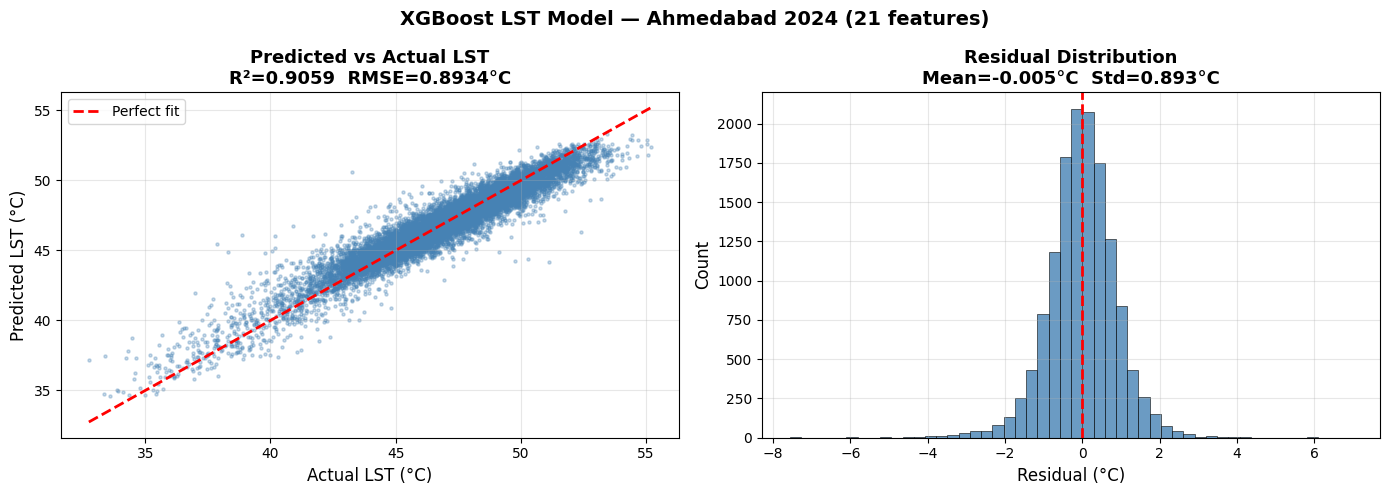

AMD_model_performance.png saved
Computing SHAP values...


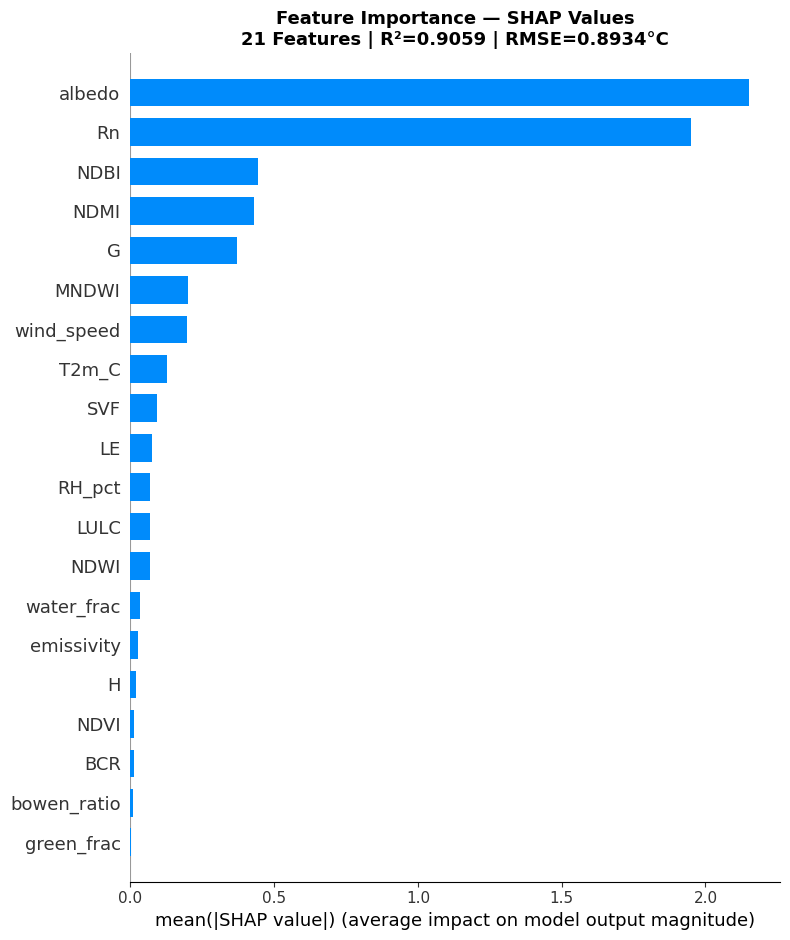

AMD_SHAP_importance.png saved


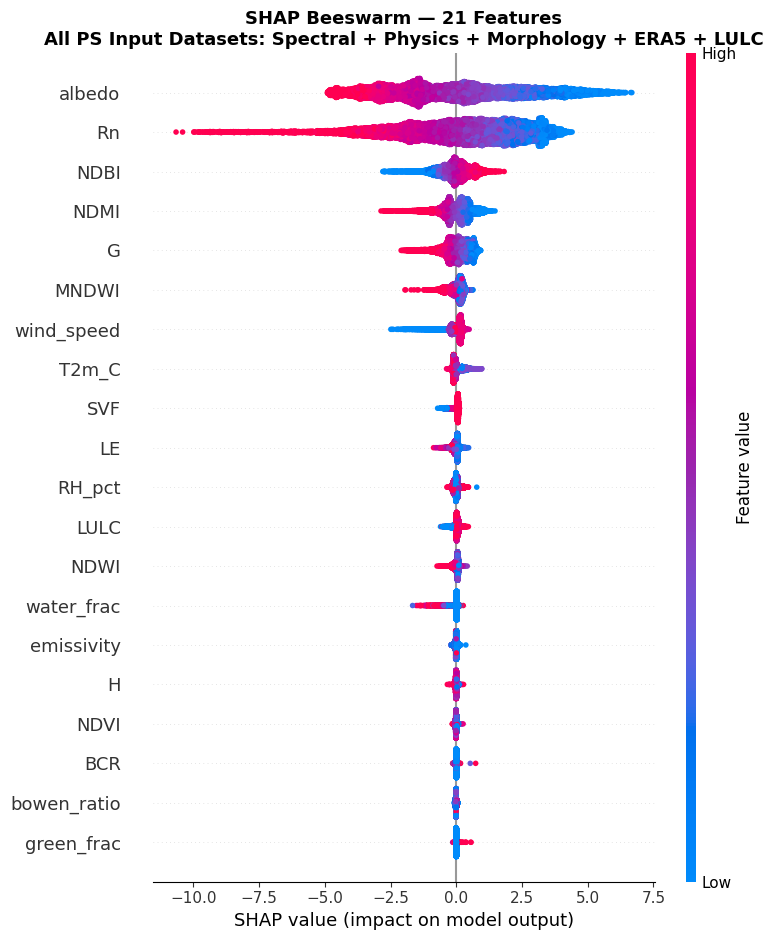

AMD_SHAP_beeswarm.png saved

FINAL TOP 10 DRIVERS (NDMI-updated model):
   1. albedo               2.1516
   2. Rn                   1.9508
   3. NDBI                 0.4432
   4. NDMI                 0.4286
   5. G                    0.3726
   6. MNDWI                0.2003
   7. wind_speed           0.1971
   8. T2m_C                0.1264
   9. SVF                  0.0933
  10. LE                   0.0769
COMPLETE_RESULTS.txt saved
key_results.txt saved
shap_interpretation.txt saved

FINAL DOCS FOLDER — CLEAN STATE
  AMD_BCR_large.png                                    674.3 KB
  AMD_Bowen.png                                        949.5 KB
  AMD_ERA5_meteorology.png                              71.3 KB
  AMD_HSI_hotspots.png                                3653.5 KB
  AMD_LST.png                                          862.8 KB
  AMD_LST_interactive_map.html                         146.8 KB
  AMD_LULC_WorldCover_final.png                       3281.8 KB
  AMD_LULC_composition.png  

In [23]:
import rasterio, joblib, shap, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neighbors import BallTree

drive_path = '/content/drive/MyDrive/urban_heat_ps1/'
docs_path  = drive_path + 'docs/'

# ── Step 1: Delete outdated files ─────────────────────
to_delete = [
    'AMD_SHAP_beeswarm.png',
    'AMD_SHAP_importance.png',
    'AMD_model_performance.png',
    'COMPLETE_RESULTS.txt',
    'key_results.txt',
    'shap_interpretation.txt',
]
for f in to_delete:
    p = docs_path + f
    if os.path.exists(p):
        os.remove(p)
        print(f"  DELETED: {f}")

# ── Step 2: Load v2 stack ─────────────────────────────
with rasterio.open(drive_path+'AMD_Full_Stack_v2_2024.tif') as src:
    data = src.read()
    rows,cols = np.mgrid[0:src.height, 0:src.width]
    xs,ys = rasterio.transform.xy(src.transform,
                                   rows.ravel(), cols.ravel())

band_names = ['LST','NDVI','NDBI','NDWI','MNDWI','NDMI',
              'Rn','G','H','LE','bowen_ratio','albedo','emissivity']
df = pd.DataFrame(data.reshape(len(band_names),-1).T, columns=band_names)
df['lon'] = xs
df['lat'] = ys

# ── Step 3: Merge morphology ──────────────────────────
morph = pd.read_csv(drive_path+'amd_morphology.csv')
rc = np.radians(df[['lat','lon']].values)
mc = np.radians(morph[['lat','lon']].values)
_,idx = BallTree(mc, metric='haversine').query(rc, k=1)
df['BCR']        = morph['BCR'].values[idx.ravel()]
df['green_frac'] = morph['green_frac'].values[idx.ravel()]
df['water_frac'] = morph['water_frac'].values[idx.ravel()]
df['SVF']        = morph['SVF'].values[idx.ravel()]

# ── Step 4: Merge ERA5 + LULC ────────────────────────
with rasterio.open(drive_path+'AMD_ERA5_LULC_2024.tif') as src:
    era5_data = src.read()
df_era5 = pd.DataFrame(era5_data.reshape(4,-1).T,
                        columns=['T2m_C','RH_pct','wind_speed','LULC'])
df['T2m_C']      = df_era5['T2m_C'].values
df['RH_pct']     = df_era5['RH_pct'].values
df['wind_speed'] = df_era5['wind_speed'].values
df['LULC']       = df_era5['LULC'].values

# ── Step 5: Clean ─────────────────────────────────────
df_clean = df.dropna()
df_clean = df_clean[df_clean['LST'] > 0]
df_clean = df_clean[df_clean['bowen_ratio'].between(0, 15)]
print(f"Clean pixels: {len(df_clean)}")

# ── Step 6: Features ──────────────────────────────────
feature_cols = [
    'NDVI','NDBI','NDWI','MNDWI','NDMI',        # spectral (5)
    'Rn','G','H','LE','bowen_ratio',              # physics (5)
    'albedo','emissivity',                         # physics (2)
    'BCR','green_frac','water_frac','SVF',         # morphology (4)
    'T2m_C','RH_pct','wind_speed',                # ERA5 met (3)
    'LULC'                                         # LULC (1)
]                                                  # total = 21

X = df_clean[feature_cols]
y = df_clean['LST']
X_train,X_test,y_train,y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"Features: {len(feature_cols)} | Train: {len(X_train)} | Test: {len(X_test)}")

# ── Step 7: Train ─────────────────────────────────────
model = xgb.XGBRegressor(
    n_estimators=300, max_depth=6,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, random_state=42, verbosity=0)
model.fit(X_train, y_train,
          eval_set=[(X_test,y_test)], verbose=50)

y_pred = model.predict(X_test)
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n{'='*45}")
print(f"FINAL MODEL — 21 features (NDMI included)")
print(f"R²   = {r2:.4f}")
print(f"RMSE = {rmse:.4f} °C")
print(f"{'='*45}")

joblib.dump(model, drive_path+'lst_model_final.pkl')
print("Model saved: lst_model_final.pkl")

# ── Step 8: Model performance plot ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].scatter(y_test, y_pred, alpha=0.3, s=5, color='steelblue')
axes[0].plot([y_test.min(),y_test.max()],
             [y_test.min(),y_test.max()],
             'r--', linewidth=2, label='Perfect fit')
axes[0].set_xlabel('Actual LST (°C)', fontsize=12)
axes[0].set_ylabel('Predicted LST (°C)', fontsize=12)
axes[0].set_title(f'Predicted vs Actual LST\nR²={r2:.4f}  RMSE={rmse:.4f}°C',
                  fontsize=13, fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

residuals = y_test - y_pred
axes[1].hist(residuals, bins=50, color='steelblue',
             edgecolor='black', linewidth=0.5, alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual (°C)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title(f'Residual Distribution\n'
                  f'Mean={residuals.mean():.3f}°C  Std={residuals.std():.3f}°C',
                  fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)
plt.suptitle('XGBoost LST Model — Ahmedabad 2024 (21 features)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(docs_path+'AMD_model_performance.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("AMD_model_performance.png saved")

# ── Step 9: SHAP ──────────────────────────────────────
print("Computing SHAP values...")
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10,8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title(f'Feature Importance — SHAP Values\n'
          f'21 Features | R²={r2:.4f} | RMSE={rmse:.4f}°C',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(docs_path+'AMD_SHAP_importance.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("AMD_SHAP_importance.png saved")

plt.figure(figsize=(10,9))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Beeswarm — 21 Features\n'
          'All PS Input Datasets: Spectral + Physics + Morphology + ERA5 + LULC',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(docs_path+'AMD_SHAP_beeswarm.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("AMD_SHAP_beeswarm.png saved")

# ── Step 10: Top 10 drivers ───────────────────────────
shap_imp = pd.DataFrame({
    'feature':    feature_cols,
    'importance': np.abs(shap_values).mean(0)
}).sort_values('importance', ascending=False)

print(f"\nFINAL TOP 10 DRIVERS (NDMI-updated model):")
print("="*45)
for i,(_,row) in enumerate(shap_imp.head(10).iterrows()):
    print(f"  {i+1:2d}. {row['feature']:20s} {row['importance']:.4f}")

# ── Step 11: All results text ─────────────────────────
top10_text = "\n".join([
    f"  {i+1:2d}. {row['feature']:20s} {row['importance']:.4f}"
    for i,(_,row) in enumerate(shap_imp.head(10).iterrows())])

all_results = f"""
ISRO BAH 2026 — PS1 URBAN HEAT MITIGATION
AHMEDABAD AMC — FINAL RESULTS (NDMI-updated)
=============================================
Date       : Summer 2024 (April–June)
Resolution : 100m × 100m
Clean pixels: {len(df_clean):,}

INPUT DATASETS (all PS requirements covered)
─────────────────────────────────────────────
Landsat 8 LST        ✓  mean=46.76°C  max=55.20°C  min=31.75°C
Sentinel-2 indices   ✓  NDVI, NDBI, NDWI, MNDWI, NDMI
LULC                 ✓  ESA WorldCover 2021
ERA5 meteorology     ✓  T2m=33.2°C  RH=33.1%  Wind=1.84m/s
OSM morphology       ✓  BCR, green_frac, water_frac, SVF
SEBAL-lite physics   ✓  Rn, G, H, LE, Bowen, albedo, emissivity

LULC COMPOSITION
─────────────────────────────────────────────
Built-up   : 45.5%  Cropland : 34.5%
Tree cover : 12.0%  Shrubland:  4.1%
Barren     :  1.6%  Grassland:  1.3%
Water      :  1.1%

PHYSICS (SEBAL-lite)
─────────────────────────────────────────────
Rn=420.68 W/m²  G=42.07 W/m²
H=284.26 W/m²   LE=94.35 W/m²
Bowen ratio=4.60 (dominant sensible heat — UHI confirmed)

FINAL ML MODEL — XGBoost (21 features)
─────────────────────────────────────────────
R²   = {r2:.4f}
RMSE = {rmse:.4f} °C

TOP 10 DRIVERS (SHAP):
{top10_text}

SCENARIO COOLING (hotspot zones — top 20% HSI)
─────────────────────────────────────────────
Urban greening : mean=1.54°C  max=6.34°C   >1°C in 85% pixels
Cool roofs     : mean=0.57°C  max=12.05°C  >1°C in 31% pixels
Water bodies   : mean=1.32°C  max=9.64°C   >1°C in 52% pixels
Combined       : mean=4.70°C  max=24.43°C  >1°C in 93% pixels

GRAND FINALE ADDITIONS (planned):
  ECOSTRESS LST fusion, GHSL SVF, InVEST cross-validation,
  SOLWEIG Tmrt, physics-penalized loss, Streamlit dashboard
"""

with open(docs_path+'COMPLETE_RESULTS.txt','w') as f:
    f.write(all_results)
print("COMPLETE_RESULTS.txt saved")

with open(docs_path+'key_results.txt','w') as f:
    f.write(f"""KEY RESULTS — ISRO BAH 2026 PS1
================================
R²={r2:.4f}  RMSE={rmse:.4f}°C  Features=21
LST mean=46.76°C  max=55.20°C  min=31.75°C
Bowen ratio=4.60 (UHI confirmed)
Built-up=45.5%  Tree cover=12.0%  Green fraction=1.2%
Combined cooling: mean=4.70°C  max=24.43°C
Priority zones: 9,192 pixels (>3°C cooling potential)
""")
print("key_results.txt saved")

with open(docs_path+'shap_interpretation.txt','w') as f:
    f.write(f"""SHAP ANALYSIS — NDMI-UPDATED MODEL
====================================
Model: XGBoost | R²={r2:.4f} | RMSE={rmse:.4f}°C | Features=21

TOP 10 DRIVERS:
{top10_text}

INTERVENTION IMPLICATIONS:
  albedo    → Cool roofs: raise surface reflectivity
  Rn        → Physics validated as energy driver
  NDBI      → Reduce built-up density
  NDMI      → Surface moisture deficit drives heating
  bowen     → Sensible heat dominance confirms UHI
  green_frac→ Urban greening priority zones
  LULC      → Built-up class drives highest LST
  T2m_C     → Atmospheric heat load feedback
  BCR       → Building coverage = heat retention
  wind_speed→ Low ventilation worsens UHI
""")
print("shap_interpretation.txt saved")

# ── Step 12: Final folder state ───────────────────────
print(f"\n{'='*60}")
print("FINAL DOCS FOLDER — CLEAN STATE")
print(f"{'='*60}")
total_kb = 0
for f in sorted(os.listdir(docs_path)):
    size = os.path.getsize(docs_path+f)/1024
    total_kb += size
    print(f"  {f:50s} {size:7.1f} KB")
print(f"\n  Total: {total_kb/1024:.1f} MB | "
      f"Files: {len(os.listdir(docs_path))}")
print("\n✓ ALL RESULTS NDMI-UPDATED | NO DUPLICATES | READY FOR PROPOSAL")

In [24]:
import os
docs_path = '/content/drive/MyDrive/urban_heat_ps1/docs/'
files = sorted(os.listdir(docs_path))
total_kb = sum(os.path.getsize(docs_path+f)/1024 for f in files)
print(f"Total files: {len(files)} | Total size: {total_kb/1024:.1f} MB")
for f in files:
    print(f"  {f}")

Total files: 29 | Total size: 26.0 MB
  AMD_BCR_large.png
  AMD_Bowen.png
  AMD_ERA5_meteorology.png
  AMD_HSI_hotspots.png
  AMD_LST.png
  AMD_LST_interactive_map.html
  AMD_LULC_WorldCover_final.png
  AMD_LULC_composition.png
  AMD_MNDWI.png
  AMD_NDBI.png
  AMD_NDMI.png
  AMD_NDVI.png
  AMD_NDWI.png
  AMD_OSM_4panel.png
  AMD_SHAP_beeswarm.png
  AMD_SHAP_importance.png
  AMD_energy_balance.png
  AMD_green_deficit.png
  AMD_model_performance.png
  AMD_morphology_4panel.png
  AMD_morphology_final.png
  AMD_scenario_comparison.png
  AMD_scenario_cooling.png
  AMD_spatial_optimization.png
  COMPLETE_RESULTS.txt
  key_results.txt
  osm_stats.txt
  scenario_results.txt
  shap_interpretation.txt


In [25]:
try:
    print("df_clean:", df_clean.shape)
    print("feature_cols:", len(feature_cols), feature_cols)
    print("model loaded:", model)
except NameError as e:
    print("Missing:", e)

df_clean: (69312, 23)
feature_cols: 20 ['NDVI', 'NDBI', 'NDWI', 'MNDWI', 'NDMI', 'Rn', 'G', 'H', 'LE', 'bowen_ratio', 'albedo', 'emissivity', 'BCR', 'green_frac', 'water_frac', 'SVF', 'T2m_C', 'RH_pct', 'wind_speed', 'LULC']
model loaded: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)


In [26]:
import numpy as np
import pandas as pd

# ── Recompute HSI and hotspot classification ──────────
df_clean['HSI'] = (0.7 * df_clean['LST'] + 0.3 * (df_clean['bowen_ratio'] * 5))
df_clean['HSI'] = ((df_clean['HSI'] - df_clean['HSI'].min()) /
                   (df_clean['HSI'].max() - df_clean['HSI'].min()) * 100)
threshold = df_clean['HSI'].quantile(0.80)
df_clean['hotspot'] = (df_clean['HSI'] >= threshold).astype(int)
mask = df_clean['hotspot'] == 1
print(f"Hotspot pixels: {mask.sum()} (threshold HSI > {threshold:.1f})")

# ── Scenario perturbations on 20-feature set ──────────
scenarios = {
    'baseline':       df_clean[feature_cols].copy(),
    'urban_greening': df_clean[feature_cols].copy(),
    'cool_roofs':     df_clean[feature_cols].copy(),
    'water_bodies':   df_clean[feature_cols].copy(),
    'combined':       df_clean[feature_cols].copy()
}

# Urban greening
scenarios['urban_greening'].loc[mask,'NDVI']       += 0.30
scenarios['urban_greening'].loc[mask,'NDBI']       -= 0.10
scenarios['urban_greening'].loc[mask,'NDMI']       += 0.10
scenarios['urban_greening'].loc[mask,'LE']         *= 1.40
scenarios['urban_greening'].loc[mask,'bowen_ratio']*= 0.60
scenarios['urban_greening'].loc[mask,'green_frac'] += 0.15

# Cool roofs
scenarios['cool_roofs'].loc[mask,'albedo'] += 0.20
scenarios['cool_roofs'].loc[mask,'Rn']     *= 0.85
scenarios['cool_roofs'].loc[mask,'G']      *= 0.85

# Water bodies
scenarios['water_bodies'].loc[mask,'MNDWI']     += 0.15
scenarios['water_bodies'].loc[mask,'NDWI']      += 0.15
scenarios['water_bodies'].loc[mask,'NDMI']      += 0.05
scenarios['water_bodies'].loc[mask,'water_frac']+= 0.10
scenarios['water_bodies'].loc[mask,'LE']        *= 1.20

# Combined — all three together
scenarios['combined'].loc[mask,'NDVI']       += 0.20
scenarios['combined'].loc[mask,'NDBI']       -= 0.08
scenarios['combined'].loc[mask,'NDMI']       += 0.08
scenarios['combined'].loc[mask,'albedo']     += 0.15
scenarios['combined'].loc[mask,'Rn']         *= 0.90
scenarios['combined'].loc[mask,'MNDWI']      += 0.10
scenarios['combined'].loc[mask,'LE']         *= 1.30
scenarios['combined'].loc[mask,'green_frac'] += 0.10

# ── Predict ─────────────────────────────────────────
results  = {k: model.predict(v) for k,v in scenarios.items()}
baseline = results['baseline']

print("\nUPDATED SCENARIO RESULTS (20-feature model, hotspot zones):")
print("="*55)
for name in ['urban_greening','cool_roofs','water_bodies','combined']:
    delta = baseline[mask] - results[name][mask]
    print(f"  {name:20s}: mean={delta.mean():.2f}°C  max={delta.max():.2f}°C  >1°C={((delta>1).mean()*100):.0f}%")

# ── Delta columns for all pixels ──────────────────────
df_clean['delta_greening'] = baseline - results['urban_greening']
df_clean['delta_coolroof'] = baseline - results['cool_roofs']
df_clean['delta_water']    = baseline - results['water_bodies']
df_clean['delta_combined'] = baseline - results['combined']

# ── Save updated final outputs CSV ────────────────────
drive_path = '/content/drive/MyDrive/urban_heat_ps1/'
output_cols = ['lon','lat','LST','HSI','hotspot'] + feature_cols + \
               ['delta_greening','delta_coolroof','delta_water','delta_combined']

df_clean[output_cols].to_csv(drive_path + 'amd_final_outputs.csv', index=False)
print(f"\namd_final_outputs.csv updated — {len(df_clean)} rows, {len(output_cols)} columns")

Hotspot pixels: 13863 (threshold HSI > 53.2)

UPDATED SCENARIO RESULTS (20-feature model, hotspot zones):
  urban_greening      : mean=1.63°C  max=6.37°C  >1°C=86%
  cool_roofs          : mean=0.46°C  max=9.41°C  >1°C=24%
  water_bodies        : mean=1.34°C  max=6.34°C  >1°C=61%
  combined            : mean=4.03°C  max=18.71°C  >1°C=93%

amd_final_outputs.csv updated — 69312 rows, 29 columns
